# A simple base script to display AIOLOS data

This shows a simple function which can be used to plot either time-sequence simulation data with AIOLOS (Schulik&Booth2023) or compare different simulation outcomes against each other.
The plotted example data is an analogue of the HD189733b simulations from Schulik&Owen 2025.

In [6]:

import os
import numpy as np
import copy
from scipy import *
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection

from scipy.special import lambertw
from matplotlib.lines import Line2D
matplotlib.get_backend()

font = {'family': 'serif',
        'color':  'red',
        'weight': 'normal',
        'size': 19,
        }


left1, bottom1, width1, height1 = [0.095, 0.545, 0.88, 0.43]
left2, bottom2, width2, height2 = [0.095, 0.05, 0.88, 0.43]

kb = 1.38e-16
amu= 1.66e-24
G  = 6.678e-8

pi = 3.141592
mearth   = 5.98e27
rearth   = 6370e5
year      = 365*24*3600

rjupiter = 70000*1e5
rsolar   = 10.*rjupiter

lsolar = 3.83e33 #erg/s
matmo  = 6e21

rpl = 9.45e9


def get_filelength(dirr, file):
    
    count=0
    with open(dirr + file, 'r') as fp:
        for count, line in enumerate(fp):
            pass
    return count-2

def analytic_wind_solution(mplanet, mparticle, T, radii, gamma_ad = 1.):
    
    mpl= mplanet*6e27
    cs     = np.sqrt(gamma_ad * kb*T/(mparticle*amu))
    rsonic = 0.5*G*mpl/cs**2.
    rrc           = radii/rsonic;
    D             = rrc**(-4.) * exp(4.*(1.-1./rrc)-1.);
    lamb0  = cs/(gamma_ad)*np.sqrt( -lambertw(-D, 0)).real
    lambm1 = cs/(gamma_ad)*np.sqrt( -lambertw(-D, -1)).real
    
    print("in analytic, rs/rp = ")
    print(rsonic/rpl)
    
    u_analytic = [ lamb0[i] if radii[i]<rsonic else lambm1[i] for i, rrc in enumerate(rrc)]
    
    return rsonic, cs, u_analytic


def analytic_deltaw(m1, m2, radii, n1, n2, temperature, pressure):
    n  = n1+n2
    fi = n1/(n2+n1)
    g  = -G*224*mearth/(radii*radii)
    
    b = 5.0e17 * (temperature/300.)**0.75
    #D = b/n
    D = kb/(m1*amu)*temperature*n2/n/b
    
    #t1 =   n*n/(n1*n2) * np.gradient(n1/n, radii) 
    t1 =   n/(n1*n2) * np.gradient(n1, radii) * (1.-n1/n) 
    t2 = - 1/n2      * np.gradient(n2, radii) 
    #t2 = 0.
    t3 = +(m2-m1)/(m1+m2) * np.gradient(pressure, radii) / pressure
    t4 = g*(m2-m1)/(kb*temperature)
    
    l1 = b*fi/(1+fi)
    l2 = -(m1-m2)*g/(kb * temperature)
    
    limitflux = l1 * l2
    dw        =  - D * (t1 + t2 + t3 + t4)
    
    return limitflux, dw

def analytic_deltaw2(m1, m2, radii, n1, n2, temperature, pressure):
    fi    = n2/n1
    dfidr = np.gradient(fi,radii)
    
    t1  = dfidr/fi
    t2  = G*224*mearth/(radii*radii)/(kb*temperature*(m2-m1))
    
    b = 5.0e17 * (temperature/300.)**0.75
    
    print(" b.shape = " + repr(b.shape))
    print(" n1.shape = " + repr(n1.shape))
    print(" t1.shape = " + repr(t1.shape))
    print(" t2.shape = " + repr(t2.shape))
    
    return b/n1*(t1+t2)

def analytic_deltaw3(m1, m2, radii, n1, n2, temperature, pressure):
    n     = n1+n2
    fi    = n2/n
    dfidr = np.gradient(fi,radii)
    
    t1  = dfidr * n*n/n1/n2
    dpdr = np.gradient(pressure,radii)
    t2   = (m2-m1)/(m1+m2)/pressure*dpdr
    #t2  = G*224*mearth/(radii*radii)/(kb*temperature*(m2-m1))
    
    b = 5.0e17 * (temperature/300.)**0.75
    
    print(" b.shape = " + repr(b.shape))
    print(" n1.shape = " + repr(n1.shape))
    print(" t1.shape = " + repr(t1.shape))
    print(" t2.shape = " + repr(t2.shape))
    
    return b/n1*(t1-t2)

def get_escape_flux(m1, m2, hydrogen_flux, T0, alpha_multipl):

    b     = alpha_multipl * 5.0e17 * (T0/300.)**0.75
    nom   = hydrogen_flux * kb * T0 
    denom = m1/m2 * G *244.*mearth * b
    
    return nom/denom

def parker_massloss(T, mplanet,mparticle, rplanet, dens0, gamma_ad):
    
    rp     = rplanet * rearth
    mpl    = mplanet*mearth
    cs     = np.sqrt(gamma_ad*kb*T/(mparticle*amu))
    rsonic = 0.5*G*mpl/cs**2.
    dens_computed = dens0*exp(-G*mpl/cs**2.*(1/rp-1/rsonic))
    
    print(" in parker_masslos, cs, rs, rho_0 , dens_computed = " + repr([cs,rsonic,dens0, dens_computed]))
    iso_mdot2 = 3.141592*(G*mpl)**2/cs**3.*dens_computed
    
    #return 4.*3.141592*rsonic**2.*cs*dens_computed
    return iso_mdot2

def get_analytic_density_ratio(mp, T0, m0, m1, frac0, flux0, flux1, r0, r):
    
    b         = 5.0e17 * (T0/300.)**0.75
    redflux   = flux0 - G*mp*(m1-m0)*b/(kb*T0)
    fluxratio = flux1/redflux
    
    t1 = frac0 - fluxratio
    
    print(" In get analytic_density, GMdmb/kT = " + repr(G*mp*(m1-m0)*b/(kb*T0)) + " redflux=f0-GMdmb/kT = " + repr(redflux) + " flux0 = " + repr(flux0) + " flux1 = " + repr(flux1)  + " fluxratio=flux1/redflux = " +repr(fluxratio) + " frac0 - fluxratio = " + repr(frac0-fluxratio) )
    print(" exp(redflux/b/r0) = " + repr(np.exp(redflux/b*(1./r0)) ) + " t1*t2 = " + repr(t1*np.exp(redflux/b*(1./r0))) + " frac0 = " + repr(frac0) )
    mured    = m1/m0
    phi_crit = (mured-1.)/mured 
    phi_red  = flux0 * kb*T0/(mured*G*mp*m0*b)
    print("phi_crit = " + repr(phi_crit) + " while phi_red = " + repr(phi_red))
    
    
    t2 = np.exp(-redflux/b*(1./r0-1./r))
    return t1*t2 + fluxratio
    
def get_analytic_density_ratio2(mp, T0, m0, m1, flux0, r0, cs): #The dimensional fractionationfator at r-> infty. Somthing goes wrong here with units
    
    rs = G*mp/cs/cs/2.
    b       = 5.0e17 * (T0/300.)**0.75
    mu      = m1/m0
    phi     = flux0*kb*T0/(mu*G*mp*m0*b)
    lambda0 = rs/r0
    
    nom     = mu*phi - (mu-1.)
    denom   = mu*phi - (mu-1.)*np.exp(-lambda0* (mu*phi - (mu-1.) ) )
    
    return nom/denom

def get_analytic_density_ratio3(phi, mu, lambda0, muexp=0.): 
    
    nom     = mu*phi - (mu-1.)
    denom   = mu*phi - (mu-1.)*(mu)**muexp*np.exp(-lambda0* (mu*phi - (mu-1.) ) ) #
    
    return nom/denom

def get_analytic_density_ratio4(phi, mu, lambda0): #The analytic crossover mass by Hunten
    
    return 1.-(mu-1.)/(mu*phi)


def crossover_mass(m1, radii, T, flux, phi):
    g = np.gradient(phi, radii)
    b = 5e17*(T/300.)**0.75
    
    mc = m1 + kb * T * flux/ m1 / (b * g)
    return mc/amu


##############################################################
########## Cooling functions
##############################################################

def HOnly_cooling(nX0, nXp, Te) :

    T_HI = 157807.;
    #if (Te < 220):
    #        Te = 220.;
    
    x = 2 * T_HI / Te;
    cooling = 0;

    # Recombination Cooling:
    term = 0 ;
    #if (x < 1e5) :
    #    term = 3.435e-30 * Te * x*x / pow(1 + pow(x / 2.250, 0.376), 3.720);
    #else:
    #    term = 7.562e-27 * pow(Te, 0.42872) ;
        
    term = 3.435e-30 * Te * x*x / pow(1 + pow(x / 2.250, 0.376), 3.720);
    
    cooling += 1.* nXp * term;
    
    # Collisional ionization cooling:
    #term = kb * T_HI * H_collisional_ionization(Te);
    #cooling += 1. *nX[0] * term;

    # HI Line cooling (Lyman alpha):
    term = 7.5e-19 * exp(-0.75 * T_HI / Te); #MC2009
    cooling += 1. * nX0 * term;

    # Free-Free:
    term = 1.426e-27 * 1.3 * sqrt(Te) ;
    cooling += 1. * nXp * term  ;

    return 1.*cooling;



def C_cooling(Te):
    term = 1e-24+3.1e-20*np.exp(-15162/Te)*(1.+pow(Te/2e4, 1.5));
    return term;


def CP_cooling(Te):
    term = 1.5e-23+3.1e-20*np.exp(-45162/Te)*(1.+pow(Te/0.75e4,1.5));
    
    return term;

def O_cooling(Te):
    
    term = 5.5e-24+1.1e-20*np.exp(-30162/Te)*(1.+pow(Te/0.75e4, 0.5));
    
    return term;


def OP_cooling(Te):
    
    term = 5.1e-20*np.exp(-35162/Te)*(1.+pow(Te/0.75e4, 0.5));
    
    return term;



def plot_parameter_variation_atoms(rp, directory, sims, times, max_rrs, labels, cols, styles, title, fsize=(24.,36.)):
    
    fig0 = plt.figure(figsize=fsize) #36,24
    fig0.suptitle(title, fontsize=20)
    
    spl0 = fig0.add_subplot(431)
    spl1 = fig0.add_subplot(432)
    spl2 = fig0.add_subplot(433)
    spl3 = fig0.add_subplot(434)
    spl4 = fig0.add_subplot(435)
    spl5 = fig0.add_subplot(436)
    spl6 = fig0.add_subplot(437)
    spl7 = fig0.add_subplot(438)
    spl8 = fig0.add_subplot(439)

    spl9   = fig0.add_subplot(4,3,10)
    spl10  = fig0.add_subplot(4,3,11)
    spl11  = fig0.add_subplot(4,3,12)

    axes = [spl0, spl1, spl2, spl3, spl4, spl5, spl6, spl7, spl8, spl9, spl10, spl11]

    names = [
             r"$\rm Ion\,fraction\,H\;[1]$", r"$\rm Ion\,fraction\,He\;[1]$",r"$\rm Ion\,fraction\,CII\;[1]$",
             r"$\rm Ion\,fraction\,CIII\;[1]$", r"$\rm Ion\,fraction\,OII\;[1]$", r"$\rm Ion\,fraction\,OIII\;[1]$",
             r"$\rm Temperature\,[K]$", r"$\rm Velocity\,[m\,s^{-1}]$", r"$\rm H_{tot}\; Mass\,flux\,[m_{\oplus}\,yr^{-1}]$",
             r"$\rm Charge\; imbalance\,[n_{e-}]$", r"$\rm C_{tot}\; Mass\,flux\,[m_{\oplus}\,yr^{-1}]$", r"$\rm O_{tot}\; Mass\,flux\,[m_{\oplus}\,yr^{-1}]$",]

    masses = [5e-4, 1.,1., 4.,4.,12.,12.,12.,16.,16.,16.]
    
    #
    # For Documentation purposes: 10.000 outputs in this simulation correspond to 3e11s, or 10.000yrs
    #

    print(timesteps)
    for i,spl in enumerate(axes):
        spl.set_title(names[i], fontsize=20, pad = 1)
        spl.tick_params(axis='both', which='minor', labelsize=18, size=7,direction="in")
        spl.tick_params(axis='x', which='major', labelsize=25, size=10,direction="in");
        spl.tick_params(axis='y', which='major', labelsize=28, size=10,direction="in");
        spl.yaxis.set_ticks_position('both')
        spl.xaxis.set_ticks_position('both')
        spl.set_xlim([0.9, 10.5])

    for i,spl in enumerate([axes[-5],axes[-3], axes[-2], axes[-1]]):
        spl.set_xlabel(r'$\rm Radius \;[R_{\rm p}]$', fontsize=26)

    for i, spl in enumerate([spl0, spl1, spl2, spl3, spl4, spl5, ]):
        spl.set_ylim([1e-2, 1])

    spl7.set_ylim([1e0, 1e5])

    for i, spl in enumerate([spl8,spl10, spl11, ]):
        spl.set_ylim([1e3, 1e13])

    spl9.set_ylim([1e-3, 1e3])    
    
    mdot_conversion = 6e27/(365.*24.*3600.)

    for i,sim in enumerate(sims):
            timestep = timesteps[i]

            max_rr  = get_filelength(dirr, "output_"+ sim +"_S1_t" + repr(timestep)+ ".dat") #max_rrs[i]
            data_h0 = np.loadtxt(dirr + "output_"+ sim +"_S0_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_p  = np.loadtxt(dirr + "output_"+ sim +"_S1_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_e  = np.loadtxt(dirr + "output_"+ sim +"_e-_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)

            data_he  = np.loadtxt(dirr + "output_"+ sim +"_He_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_hep = np.loadtxt(dirr + "output_"+ sim +"_He+_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)

            data_c0  = np.loadtxt(dirr + "output_"+ sim +"_C0_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_cp  = np.loadtxt(dirr + "output_"+ sim +"_Cp_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_cpp = np.loadtxt(dirr + "output_"+ sim +"_Cpp_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)

            data_o0  = np.loadtxt(dirr + "output_"+ sim +"_O0_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_op  = np.loadtxt(dirr + "output_"+ sim +"_Op_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            data_opp = np.loadtxt(dirr + "output_"+ sim +"_Opp_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
            
            data_o3p = 0. * data_o0
            data_o4p = 0. * data_o0
            higho_switch = 0
            if os.path.isfile(dirr + "output_"+ sim +"_O3p_t" + repr(timestep)+ ".dat"): #If O3p exist, assume that O4p also exists
                data_o3p = np.loadtxt(dirr + "output_"+ sim +"_O3p_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
                data_o4p = np.loadtxt(dirr + "output_"+ sim +"_O4p_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
                higho_switch = 1
                print("Found simulation with high ionic states: " + sim)

            n_e  = data_e[:,1]/masses[0]; 
            n_p  = data_p[:,1]/masses[1]; 
            n_h0 = data_h0[:,1]/masses[2];

            n_he  = data_he[:,1]/masses[3];
            n_hep = data_hep[:,1]/masses[4];

            n_c0 = data_c0[:,1]/masses[5];
            n_cp = data_cp[:,1]/masses[6];
            n_cpp = data_cpp[:,1]/masses[7];

            n_o0 = data_o0[:,1]/masses[8];
            n_op = data_op[:,1]/masses[9];
            n_opp = data_opp[:,1]/masses[10];
            n_o3p = data_o3p[:,1]/masses[10];
            n_o4p = data_o4p[:,1]/masses[10];

            r  = data_h0[:,0]/rp
            dr = np.diff(r)*rp

            charge_ratio   = (n_p + n_hep + n_cp + 2.* n_cpp + n_op + 2. * n_opp + 3. * n_o3p + 4. * n_o4p)/n_e
            charge_balance = (n_p + n_hep + n_cp + 2.* n_cpp + n_op + 2. * n_opp + 3. * n_o3p + 4. * n_o4p - n_e)/n_e
            nctot = (n_c0 + n_cp + n_cpp )
            notot = (n_o0 + n_op + n_opp + n_o3p + n_o4p)
            
            ionfracs    = [n_p/(n_h0 + n_p), n_hep/(n_hep+n_he), n_cp/nctot, n_cpp/nctot, n_op/notot, n_opp/notot, charge_balance]  

            for s, spl in enumerate(axes):
                if s<6:
                    spl.loglog(r, ionfracs[s], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            
            if higho_switch==1:
                spl4.loglog(r, n_o3p/notot, lw=1.0, c=cols[i], ls=sstyls[i], label="")
                spl5.loglog(r, n_o4p/notot, lw=1.0, c=cols[i], ls=sstyls[i], label="")

            spl6.loglog(r, data_h0[:,12], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            spl7.loglog(r, data_h0[:,11]/1e2, lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            mom_h = data_h0[:,2] + data_p[:,2]
            mom_he= data_he[:,2] + data_hep[:,2]
            mom_o = data_o0[:,2] + data_op[:,2] + data_opp[:,2] + data_o3p[:,2] + data_o4p[:,2]
            mom_c = data_c0[:,2] + data_cp[:,2] + data_cpp[:,2]

            spl8.loglog(r, 4.*3.1413592*r*r*rp*rp * mom_h, lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            spl9.loglog(r, charge_ratio,                                    lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            spl10.loglog(r, 4.*3.1413592*r*r*rp*rp * mom_c , lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
            spl11.loglog(r, 4.*3.1413592*r*r*rp*rp * mom_o , lw=3., c=cols[i], ls=sstyls[i], label=labels[i])

            print("ratios mdot_He/mdot_H = %1.2e,  mdot_C/mdot_H = %1.2e, mdot_O/mdot_H = %1.2e, mdot_C/mdot_O = %1.2e" % (mom_he[-10]/mom_h[-10], mom_c[-10]/mom_h[-10], mom_o[-10]/mom_h[-10], mom_c[-10]/mom_o[-10] ) )
                            
            for s, spl in enumerate(axes):
                spl.legend(fontsize=18)

    spl4.axhline(y=1,c='k')
    
    return fig0

def plot_species_data(rp, directory, sims, times, max_rrs, labels, cols, styles, title, species, masses, fsize=(24.,36.)):
    
    fig0 = plt.figure(figsize=fsize) 
    #fig0.suptitle(title, fontsize=20)
    
    spl0 = fig0.add_subplot(431)
    spl1 = fig0.add_subplot(432)
    spl2 = fig0.add_subplot(433)
    spl3 = fig0.add_subplot(434)
    spl4 = fig0.add_subplot(435)
    spl5 = fig0.add_subplot(436)
    spl6 = fig0.add_subplot(437)
    spl7 = fig0.add_subplot(438)
    spl8 = fig0.add_subplot(439)
    spl9   = fig0.add_subplot(4,3,10)
    spl10  = fig0.add_subplot(4,3,11)
    spl11  = fig0.add_subplot(4,3,12)

    axes = [spl0, spl1, spl2, spl3, spl4, spl5, spl6, spl7, spl8, spl9, spl10, spl11]

    names = [
             r"$\rm Density\;[g/cm^3]$", 
             r"$\rm Number density\;[1/cm^3]$",
             r"$\rm Temperature\;[K]$",
             r"$\rm Velocity\;[cm/s]$", 
             r"$\rm Mach number\;[1]$", 
             r"$\rm Mass\; flux\;[g/s]$",
             r"$\rm Grav. potential\,[erg/g]$", 
             r"$\rm Pressure\,[bar]$", 
        r"$\rm Speed of sound\,[cm/s]$",
        r"$\rm Total \;mass\,[m_{\oplus}]$", 
        r"$\rm Heating\,[erg/cm^3/s]$",
        r"$\rm ---\,[---]$",]
    
    # 
    for i,spl in enumerate(axes):
        #spl.set_title(names[i], fontsize=20, pad = 1)
        spl.tick_params(axis='both', which='minor', labelsize=18, size=7,direction="in")
        spl.tick_params(axis='x', which='major', labelsize=25, size=10,direction="in");
        spl.tick_params(axis='y', which='major', labelsize=28, size=10,direction="in");
        spl.yaxis.set_ticks_position('both')
        spl.xaxis.set_ticks_position('both')
        spl.set_ylabel(names[i], fontsize=22)

    for i,spl in enumerate([axes[-5],axes[-3], axes[-2], axes[-1]]):
        spl.set_xlabel(r'$\rm Radius \;[R_{\rm p}]$', fontsize=22)
    
    mdot_conversion = 6e27/(365.*24.*3600.)

    for i,sim in enumerate(sims):
            timestep = timesteps[i]

            max_rr = get_filelength(dirr, "output_"+ sim +"_S1_t" + repr(timestep)+ ".dat") #max_rrs[i]
            
            for s, spc in enumerate(species):
                data = np.loadtxt(dirr + "output_"+ sim +"_"+spc+"_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr) 
                r        = data[:,0]/rp
                dr       = np.diff(r)*rp
                numdens  = data[:,1]/masses[s]/1.66e-24
                
                spl0.loglog(r, data[:,1], lw=3., c=cols[i], ls=sstyls[i], label=labels[i] + ", " + species[s])
                spl1.loglog(r, numdens, lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl2.loglog(r, data[:,12], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl3.loglog(r, data[:,11], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl3.loglog(r,-data[:,11], lw=1., c=cols[i], ls=sstyls[i], label="")
                
                spl4.loglog(r, data[:,11]/data[:,15], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl5.loglog(r, 4*3.141592*data[:,2]*data[:,0]*data[:,0], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl6.loglog(r, data[:,19], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl7.loglog(r, data[:,10]/1e6, lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                
                spl8.loglog(r, data[:,15], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl9.loglog(r, data[:,20]/6e27, lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                spl10.loglog(r, data[:,22], lw=3., c=cols[i], ls=sstyls[i], label=labels[i])
                             
            for s, spl in enumerate(axes):
                spl.legend(fontsize=13)

    spl4.axhline(y=1,c='k')
    
    fig0.tight_layout()
    return fig0


/tmp/ipykernel_3233805/221593290.py:485: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  spl.legend(fontsize=13)


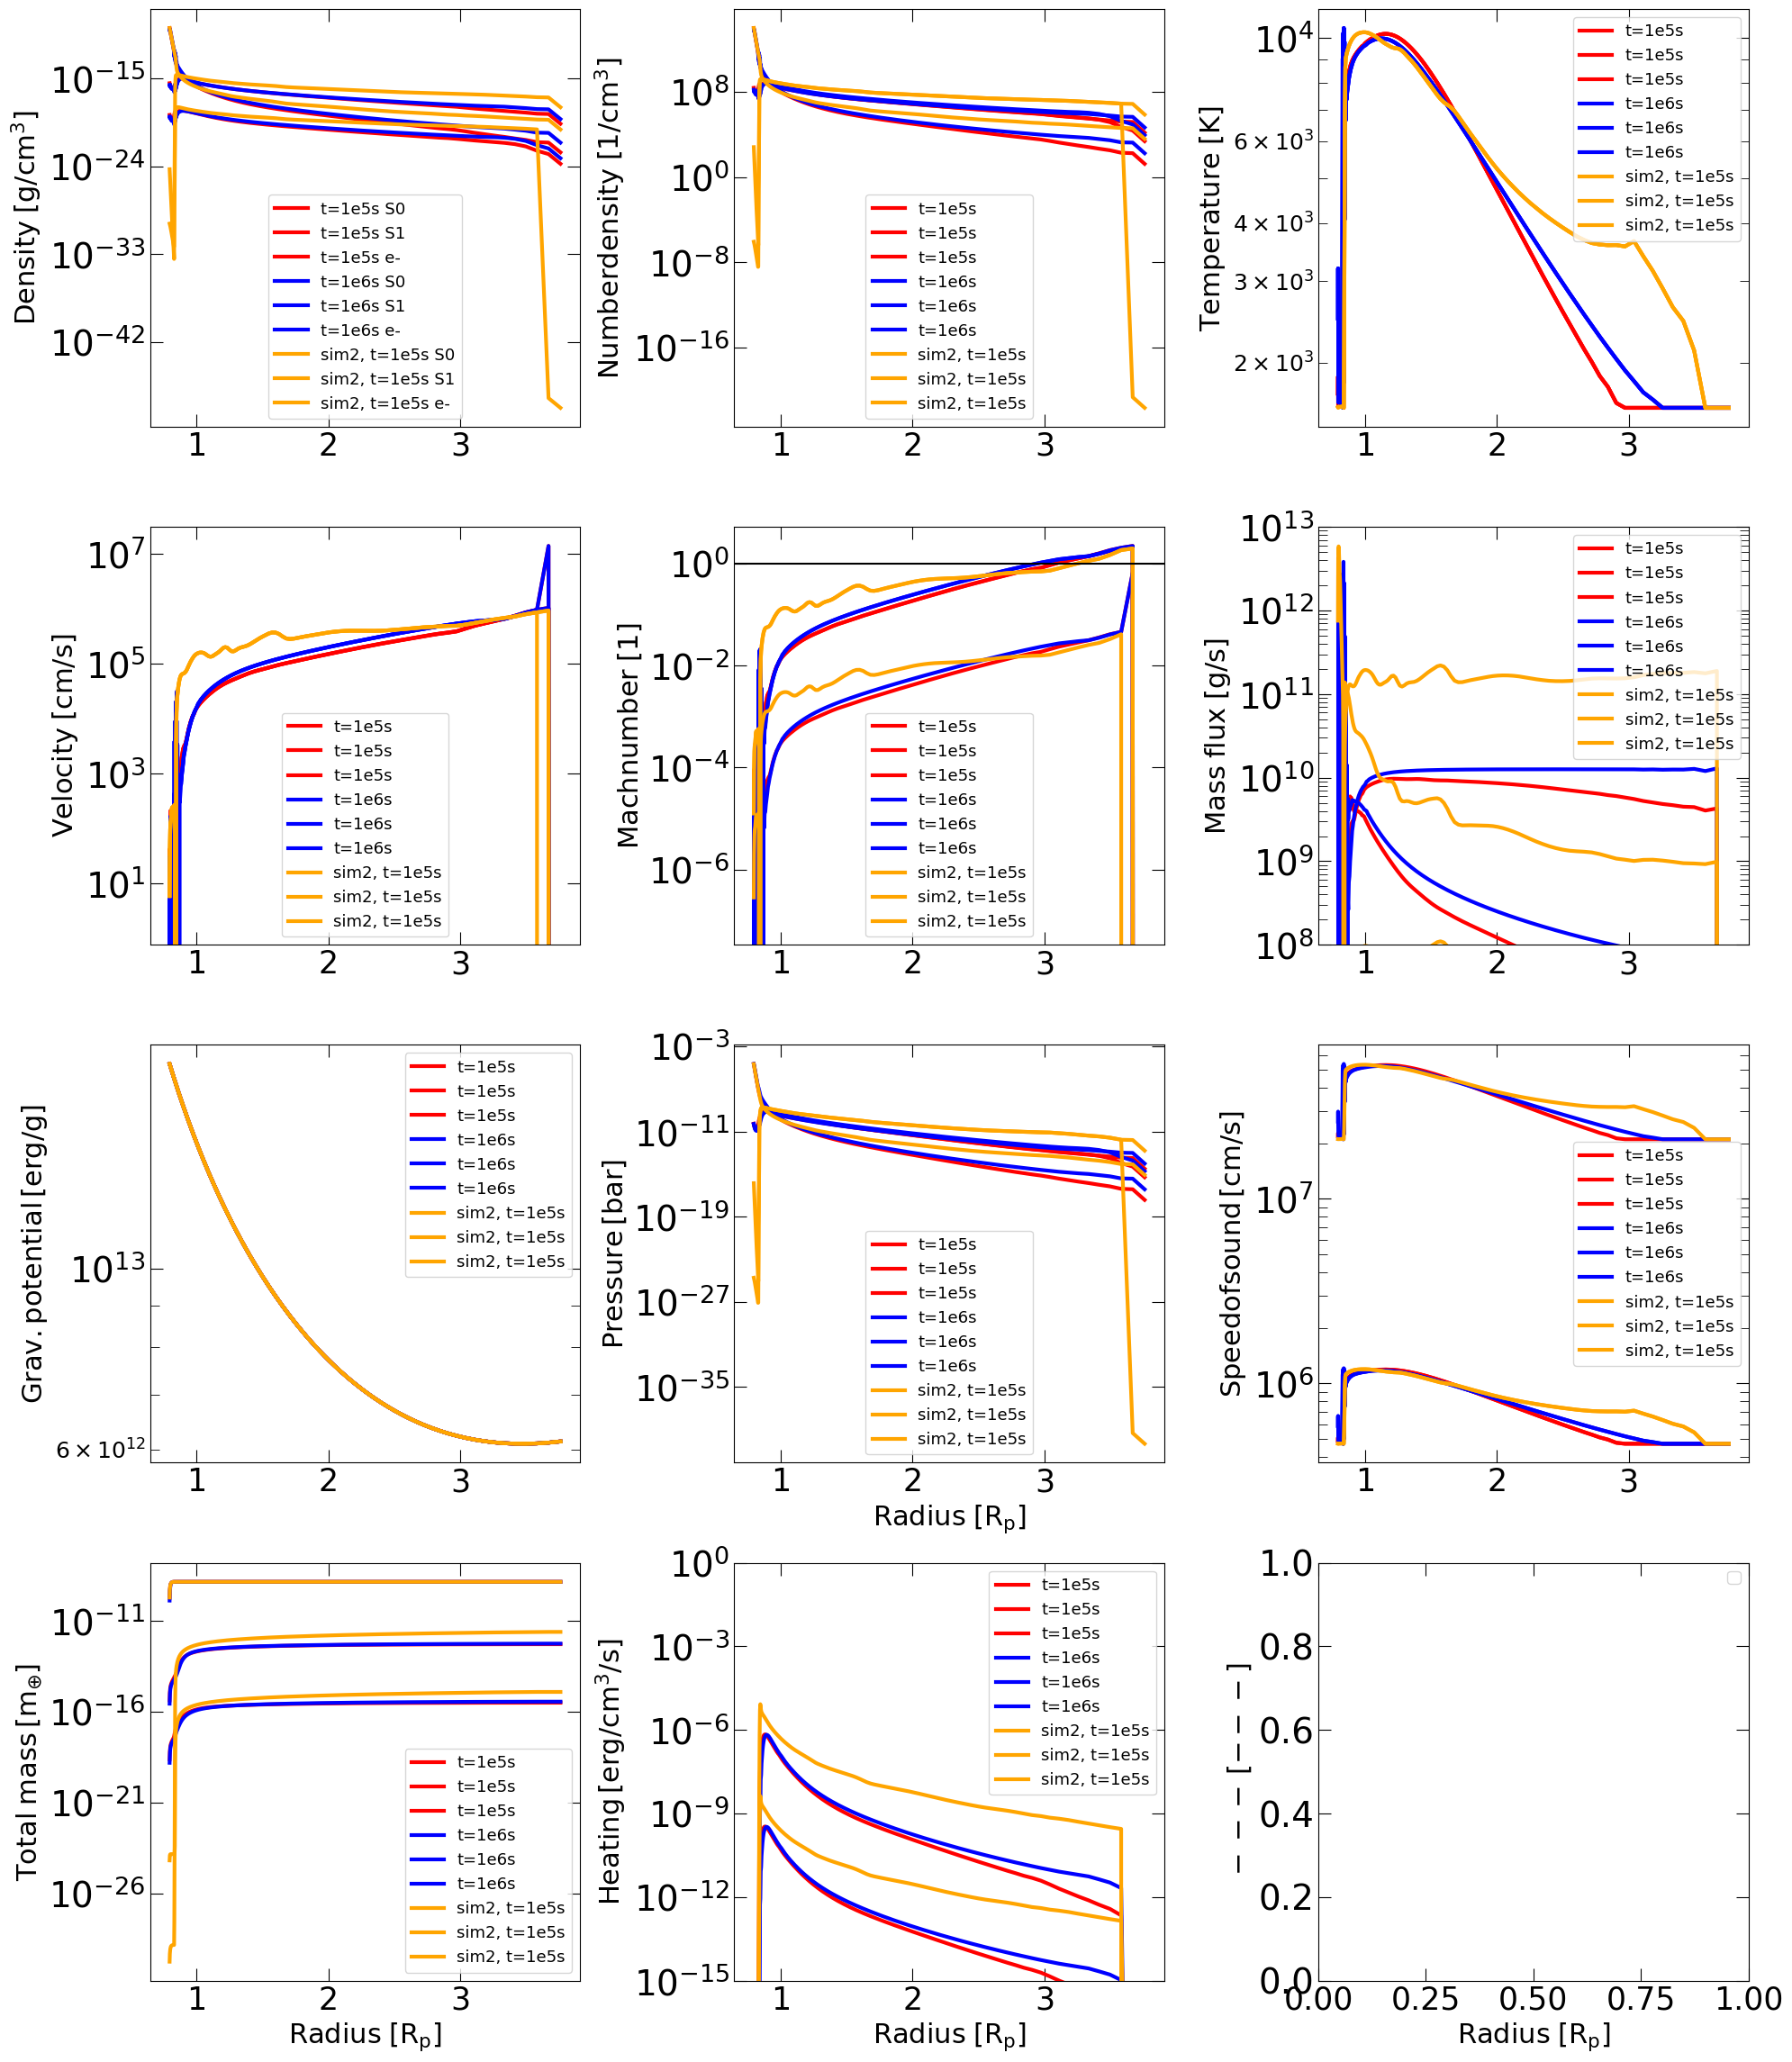

In [9]:

#

title = r"$\rm HD189733b$"

cols = ['red','blue', 'orange',  'green','red', 'red', 'red', 'magenta', 'darkgreen', 'cyan', 'magenta']
sstyls = ['-','-','-','-','-','--',':']
timesteps = [5, 6, 5]

rp = 1.00e10
dirr =  "/home/mschulik/aiolos/aiolos/hd189733b/"

sims = [
    "hd189733b-fullhelium-oxygencarbonsodium-kzz1e0_K2salz_sol2-o2-newheat2malyginNobolo-7spc-nonisothermalHD189-1600K",
    "hd189733b-fullhelium-oxygencarbonsodium-kzz1e0_K2salz_sol2-o2-newheat2malyginNobolo-7spc-nonisothermalHD189-1600K",
    "hd189733b-fullhelium-oxygencarbonsodium-kzz1e0_K2salz_sol2-o2-newheat2malyginNobolo-7spc-nonisothermalHD189-1600K-1e5erg", ]


labels = [ "t=1e5s", "t=1e6s","sim2, t=1e5s"]

species=["S0","S1","e-"] #Species0 and Species1 are neutral hydrogen and protons
masses =[1.,1.,5e-4]

fig1 = plot_species_data(rp, dirr, sims, timesteps, [], labels, cols, sstyls,title, species,masses, fsize=(20.,23.))

fig1.get_axes()[10].set_ylim([1e-15, 1e0])
fig1.get_axes()[5].set_ylim([1e8, 1e13])

f0    = 4.15e5; r0 = 1e10; m0=224.
mdot0 = 3.141592 * f0 * r0**3 / (G*m0*mearth)
fig1.get_axes()[5].axhline(mdot0,c='r')


for ax in fig1.get_axes():
    ax.set_xscale("linear")

fig1.tight_layout()
#fig1.savefig("hd209_plots.pdf",bbox_inches='tight')

In [ ]:
#Planet: (1) Mp, (2) Rp, (3) semimajor, (4) Mstar, (5) Lstar (bolometric), (6) F_XUV (and over what wavelength range this is computed, 
# or just the stellar spectrum at the planet and I can compute F_XUV over my favored range (13.6-2000eV))
#BCs: (1) Rmin, (2) density at Rmin, (3) temp at Rmin, (4) species abundances at Rmin, (5) ionization fraction of species at Rmin
# Spectrum: (1) the stellar spectrum you are using
#
species = [["S0", 1., 0, r"$\rm H^0$"],     ["S1", 1, +1, r"$\rm H^+$"],       ["e-", 5e-4, -1, r"$\rm e^-$"],
           ["He11S", 4., 0, r"$\rm He^0$"], ["He23S", 4, 0, r"$\rm He2^3S$"],  ["Hep", 4., +1,r"$\rm He^+$"] ]

for s,spc in enumerate(species):
        max_rr  = get_filelength(dirr, "output_"+ sim +"_"+species[0][0]+"_t" + repr(timestep)+ ".dat" ) #max_rrs[i]
        data    = np.loadtxt(dirr + "output_"+ sim +"_"+species[0][0]+"_t" + repr(timestep)+ ".dat",   skiprows=2, max_rows=max_rr)
